### Implemented VPG
1. for discrete action space using softmax at the end of policy netowrk
2. took normalization over advantage for reducing variance

In [21]:
!pip install -r ../requirements.txt

In [22]:
import sys
import importlib
import numpy as np
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.vpg as vpg
import configurations.config_p1_sub7 as config_path

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(vpg)
importlib.reload(config_path)

device used:  cuda


<module 'configurations.config_p1_sub7' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p1_sub7.py'>

In [23]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.vpg import VPG
from configurations.config_p1_sub7 import config

In [24]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=0,
    box_speed=2
)
vpgAgent = VPG(env, **config)

In [25]:
print(config)

{'seed': 333, 'gamma': 0.999, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.001, 'MAX_TRAIN_EPISODES': 200, 'MAX_EVAL_EPISODES': 5, 'explorationStrategyTrainFn': <function selectPolicyAction at 0x00000202E2ED56C0>, 'explorationStrategyEvalFn': <function selectPolicyGreedyAction at 0x00000202E2ED5480>, 'device': device(type='cuda'), 'valuehDim': [64, 64], 'policyhDim': [64, 64], 'model_path': '../model_weights_phase1_sub7', 'beta': 0.2, 'MAX_GRAD_NORM_POLICY': 0.5, 'MAX_GRAD_NORM_VALUE': 0.5}


In [26]:
VPGTrainRewardsList, VPGTrainTimeList, VPGEvalRewardsList, VPGWallClockTimeList, VPGTotalStepsList, VPGFinalEvalReward = vpgAgent.runVPG()

Episode 0: TR -55400.0 | ER -191916.6 | TT 16.35431146621704 | WC 61.32459306716919 | TS 1000
Episode 1: TR -989.0 | ER -995.6 | TT 73.38797426223755 | WC 124.68037438392639 | TS 1000
Episode 2: TR -1000.0 | ER -990.6 | TT 134.96539115905762 | WC 177.92544746398926 | TS 1000
Episode 3: TR -33000.0 | ER -37194.4 | TT 188.24634790420532 | WC 228.1153461933136 | TS 1000
Episode 4: TR -17800.0 | ER -993.4 | TT 239.18443322181702 | WC 278.99902415275574 | TS 1000
Episode 5: TR -19200.0 | ER -996.8 | TT 290.14888858795166 | WC 331.66689014434814 | TS 1000
Episode 6: TR -42800.0 | ER -1000.0 | TT 342.81975507736206 | WC 386.6369934082031 | TS 1000
Episode 7: TR -967.0 | ER -191677.0 | TT 398.0536210536957 | WC 441.5859684944153 | TS 1000
Episode 8: TR -972.0 | ER -156415.6 | TT 453.77720642089844 | WC 489.2484197616577 | TS 1000
Episode 9: TR -71800.0 | ER -196197.8 | TT 500.6258399486542 | WC 544.3462505340576 | TS 1000
Episode 10: TR -31000.0 | ER -154148.4 | TT 555.6274981498718 | WC 591.3

In [27]:
print(f"VPG Final Evaluation Reward: {VPGFinalEvalReward[0]} +- {VPGFinalEvalReward[1]}")

VPG Final Evaluation Reward: -996.8 +- 3.919183588453085


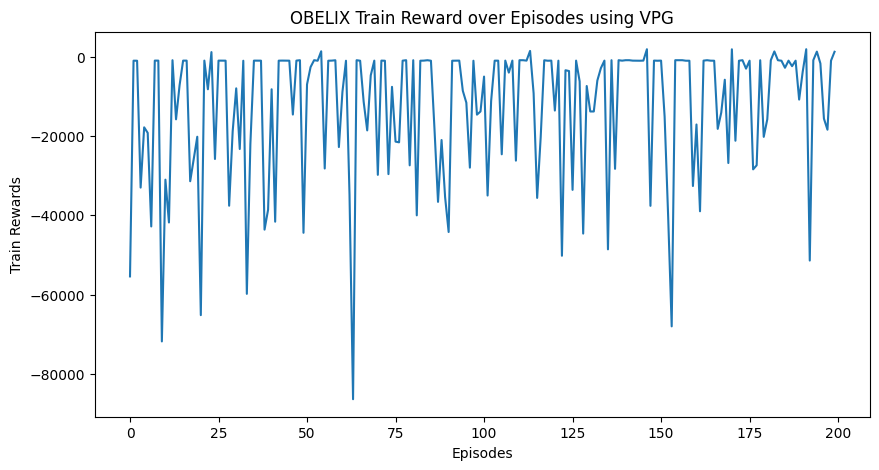

In [28]:
plotQuantity(
    VPGTrainRewardsList, 
    len(VPGTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using VPG"]    
)

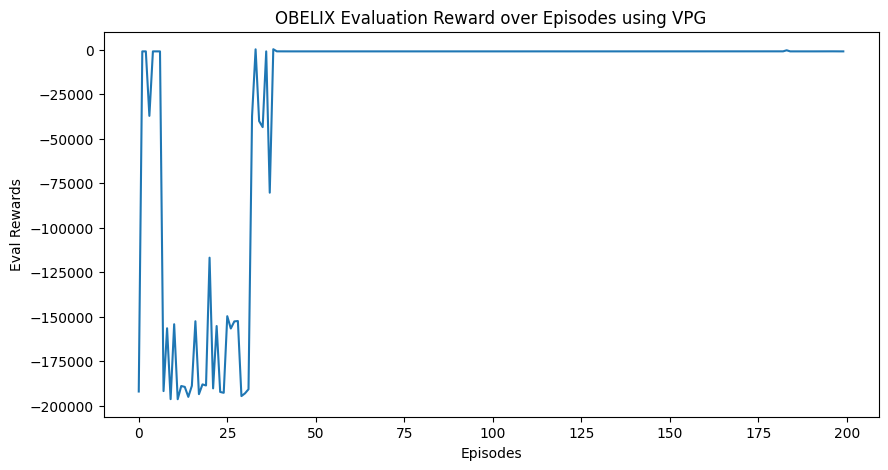

In [29]:
plotQuantity(
    VPGEvalRewardsList, 
    len(VPGEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using VPG"]    
)

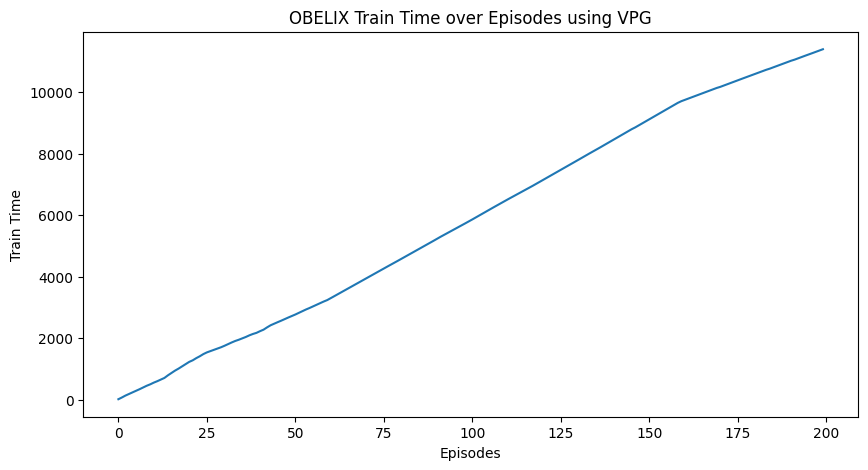

In [30]:
plotQuantity(
    VPGTrainTimeList, 
    len(VPGTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using VPG"]    
)

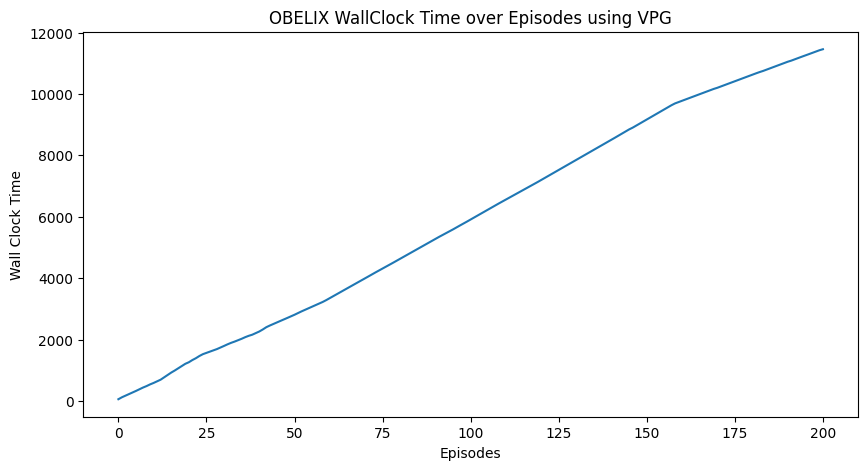

In [31]:
plotQuantity(
    VPGWallClockTimeList, 
    len(VPGWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using VPG"]    
)

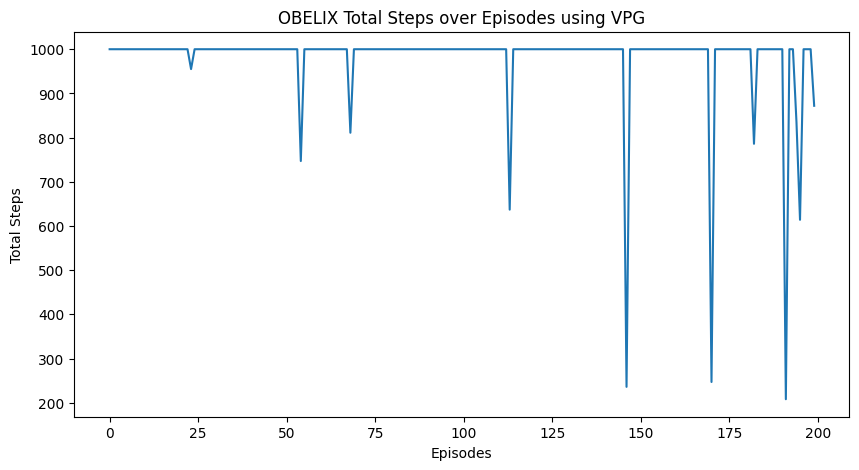

: 

In [ ]:
plotQuantity(
    VPGTotalStepsList, 
    len(VPGTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using VPG"]    
)